[Link to Colab](https://colab.research.google.com/drive/1n6IK9tg4qeSpRf4MuXT1p4Azkb4_O80Y?usp=sharing)

# Importing Data from Kaggle

In this step, the data is loaded from kaggle and imported onto the google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


For the next cell, keep the json file of the kaggle api key handy

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"qizheng15","key":"f1520eaa85fc9bcccaf7b1e7ed7e4e3d"}'}

In [ ]:
! pip install -q kaggle

In [ ]:
#Loading HAM10000 Dataset
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json
! kaggle datasets list
! kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
! mkdir ham_dataset
! unzip skin-cancer-mnist-ham10000.zip -d ham_dataset


mkdir: cannot create directory ‘/root/.kaggle’: File exists
ref                                                             title                                               size  lastUpdated          downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
muhammadehsan000/healthcare-dataset-2019-2024                   Healthcare Dataset (2019-2024)                       3MB  2024-08-09 17:52:25           2098         45  1.0              
muhammadehsan000/global-electric-vehicle-sales-data-2010-2024   Global Electric Vehicle Sales Data (2010-2024)      83KB  2024-08-09 16:39:22           1683         30  1.0              
myrios/cost-of-living-index-by-country-by-number-2024           Cost of Living Index by Country                      3KB  2024-07-19 06:25:42           4643         68  1.0              
mrmar

# **Processing Dataset (Alternative)**

In [ ]:
!pip install -q albumentations==1.2.1

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import ConcatDataset, DataLoader, Subset
import random
from collections import Counter


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from glob import glob #to walk through folder structure
import seaborn as sns #for plotting confusion matrix
from PIL import Image #for display images and format images
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim


import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader, Dataset

from scipy import stats
from sklearn.preprocessing import LabelEncoder #for formatting ouput labels

In [ ]:
#Loading the dataset as a class. The same thing as the other method but just in a class.
class HAM10000(Dataset):
  def __init__(self, csv_path, img_dir, transform=None):
    self.data = pd.read_csv(csv_path) #same as before. Reading the dataset.
    self.img_dir = img_dir
    self.transform = transform

    self.label_map = {label: index for index, label in enumerate(self.data['dx'].unique())}
    self.num_classes = len(self.label_map)

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index):
    img_name = self.data.iloc[index, 1] + '.jpg' #locates the name of the images and adds them in a dataframe. "self.data.iloc[index, 1]" -> indexing each row on the second column in the csv file

    img = None
    for img_dir in self.img_dir: #checking for available images
      img_path = os.path.join(img_dir, img_name)
      if os.path.exists(img_path):
        img = Image.open(img_path)
        break

    if img is None:
      raise FileNotFoundError(f"Image file not found: {img_path}")

    label = self.data.iloc[index, 2] #"self.data.iloc[index, 2]" -> indexing each row on the third column in the csv file. Note: Labels may be a list of tuples.
    label = self.label_map[label] #converts to integer

    if self.transform: #Applys transform onto image
      img = self.transform(img)

    label_one_hot = torch.nn.functional.one_hot(torch.tensor(label), num_classes=self.num_classes).float() #converts to one hot encoding
    return img, label_one_hot


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

metadata_path= '/content/ham_dataset/HAM10000_metadata.csv'
img_dir= ['/content/ham_dataset/HAM10000_images_part_1', '/content/ham_dataset/HAM10000_images_part_2']

dataset = HAM10000(csv_path=metadata_path, img_dir=img_dir, transform=transform)

In [ ]:
class DatasetFromList(Dataset): #just a class that gets the item(dataset) from list
  def __init__(self, data_lst):
    self.data_lst = data_lst

  def __len__(self):
    return len(self.data_lst)

  def __getitem__(self, index):
    return self.data_lst[index]

In [ ]:
def Augment_Duplicate_HAM10000(Dataset, aug_transform, target_class_count=None):
  labels = [label.argmax().item() for _,label in dataset]


  data_counts = Counter(labels) #counts the number of appearances for each unique labels in the dataset. Counter class -> Counter({'label1': 2, 'label2': 2, 'label3': 1})
  max_count = max(data_counts.values()) #locate the max number of appearances

  if not target_class_count:
    target_class_count = {label: max_count for label in data_counts} #locates the largest label in size (most frequent appearance)

  aug_data = []

  for label, count in data_counts.items():
    indices = [i for i, (_, lbl) in enumerate(dataset) if lbl.argmax().item() == label] #lbl is short for label. locates the index of the label in the dataset and adds it into a list
    num_to_duplicate = target_class_count[label] - count #Calc the difference between the size of each label and the largest label. (Have to know how many duplicates we need to normalize to the largest label)

    for _ in range(num_to_duplicate):
      idx = random.choice(indices) #idx is just grabs a random index correlating to a label. This will be the duplicate
      image, label = dataset[idx] #defines the image and label from the duplicate

      if image.shape[0] == 3:
        image_np = image.permute(1, 2, 0).numpy()

      else:
        image_np = image.numpy()


      image_np = image.permute(1, 2, 0).numpy() #Convert to numpy
      image_np = (image_np * 255).astype(np.uint8)
      image = Image.fromarray(image_np) #Convert to PIL image mememory
      image_rgb = image.convert('RGB') #Convert to rgb image
      aug_image = aug_transform(image=np.array(image_rgb))['image'] #Applies augmentations to image and adds to list

      if aug_image.shape[-1] == 3:
        aug_image_tensor = aug_image.permute(2, 0, 1)

      else:
        aug_image_tensor = aug_image.clone().detach()


      aug_image = aug_image.float()/255.0 #Normalizes the image

      aug_data.append((aug_image, label))

    aug_dataset = DatasetFromList(aug_data) #Adds all augmented data into one dataset
    return ConcatDataset([dataset, aug_dataset]) #Adds augmented duplicate dataset to og dataset


In [ ]:
#define a bunch of augmentations and their specs
aug_transform = A.Compose([
    A.Resize(height=224, width=224),
    A.RandomRotate90(),
    A.Flip(),
    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 50.0)),
    ], p=0.2),
    A.OneOf([
        A.MotionBlur(p=0.2),
        A.MedianBlur(blur_limit=3, p=0.1),
        A.Blur(blur_limit=3, p=0.1),
    ], p=0.2),
    A.OneOf([
        A.Sharpen(),
        A.RandomBrightnessContrast(),
    ], p=0.3),
    A.LongestMaxSize(max_size=224),
    A.PadIfNeeded(min_height=224, min_width=224, border_mode=0),
    ToTensorV2()
])

In [ ]:
#split the og dataset into train and test
labels_og = [label for _, label in dataset]

#split the testing index from untouched dataset 80/20 test, train
train_val_index, test_index = train_test_split(np.arange(len(dataset)), test_size=0.2, random_state=42, stratify = labels_og)

#create test subset
test_dataset = Subset(dataset, test_index)

#create a subset from original dataset (80% of remainging) to augment
remaining_dataset= Subset(dataset, train_val_index)

aug_dataset = Augment_Duplicate_HAM10000(remaining_dataset, aug_transform)

In [ ]:
#Dataloader functions
labels = [label for _, label in aug_dataset]

#Stratified split (60-20-20)

train_index, val_index = train_test_split(np.arange(len(aug_dataset)), test_size=0.25, stratify=labels, random_state=42) #splitting the dataset into 80% train-val(train_index in this case) data and 20% testing data
#Assigning the data to each index
train_dataset = Subset(aug_dataset, train_index)
val_dataset = Subset(aug_dataset, val_index)


def get_dataLoader(dataset, batch_size):
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)


  return train_loader, val_loader


bs=128
train_loader, val_loader = get_dataLoader(aug_dataset, batch_size=bs)
test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=True)

In [ ]:
#this is a checkpoint cell to see the shapes of the loaders
for images, labels in train_loader:
  print(images.shape)
  print(labels.shape)
  break

for images, labels in test_loader:
  print(images.shape)
  print(labels.shape)
  break

for images, labels in val_loader:
  print(images.shape)
  print(labels.shape)
  break

torch.Size([128, 3, 224, 224])
torch.Size([128, 7])
torch.Size([128, 3, 224, 224])
torch.Size([128, 7])
torch.Size([128, 3, 224, 224])
torch.Size([128, 7])


In [ ]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# **Visualizing the Dataset:**


Analyze the metadata:

image_id = unique id assigned to all images \\
dx column = classification (diagnosis) \\
dx_type = how the diagnoisis was confirmed \\
localization = part of body with skin lession


In [ ]:
#establish path to metadata.csv
metadata_path= '/content/ham_dataset/HAM10000_metadata.csv'
metadata = pd.read_csv(metadata_path)
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Process the data, lets convert the diagnoises types into numerical catagories
and save as new column

In [ ]:
label_encoder= LabelEncoder()
label_encoder.fit(metadata['dx'])
metadata['label'] = label_encoder.transform(metadata['dx'])

#move the new column beside the dx
metadata = metadata[['lesion_id', 'image_id', 'label', 'dx', 'dx_type','age', 'sex',	'localization']]
img_path={os.path.splitext(os.path.basename(x))[0]: x for x in glob(os.path.join('/content/ham_dataset/HAM10000_images_part_1', '*.jpg'))}
img_path.update({os.path.splitext(os.path.basename(x))[0]: x for x in glob(os.path.join('/content/ham_dataset/HAM10000_images_part_2', '*.jpg'))})
metadata['path'] = metadata['image_id'].map(img_path.get)
metadata.head(-5)


,lesion_id,image_id,label,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,2,bkl,histo,80.0,male,scalp,/content/ham_dataset/HAM10000_images_part_1/IS...
1,HAM_0000118,ISIC_0025030,2,bkl,histo,80.0,male,scalp,/content/ham_dataset/HAM10000_images_part_1/IS...
2,HAM_0002730,ISIC_0026769,2,bkl,histo,80.0,male,scalp,/content/ham_dataset/HAM10000_images_part_1/IS...
3,HAM_0002730,ISIC_0025661,2,bkl,histo,80.0,male,scalp,/content/ham_dataset/HAM10000_images_part_1/IS...
4,HAM_0001466,ISIC_0031633,2,bkl,histo,75.0,male,ear,/content/ham_dataset/HAM10000_images_part_2/IS...
...,...,...,...,...,...,...,...,...,...
10005,HAM_0005579,ISIC_0028393,0,akiec,histo,80.0,male,face,/content/ham_dataset/HAM10000_images_part_1/IS...
10006,HAM_0004034,ISIC_0024948,0,akiec,histo,55.0,female,face,/content/ham_dataset/HAM10000_images_part_1/IS...
10007,HAM_0001565,ISIC_0028619,0,akiec,histo,60.0,female,face,/content/ham_dataset/HAM10000_images_part_1/IS...
10008,HAM_0001576,ISIC_0033705,0,akiec,histo,60.0,male,face,/content/ham_dataset/HAM10000_images_part_2/IS...


Visualize the data up to this point in the processing part


Text(0.5, 0, 'Cell Type')

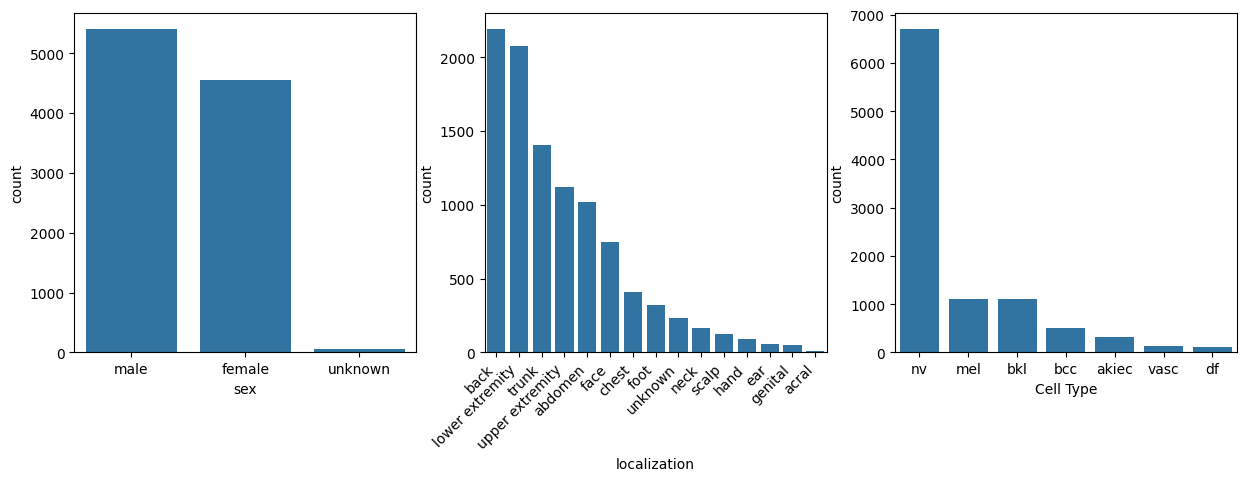

In [ ]:
#plot the sex, localization, and dx
figures= plt.figure(figsize=(15,15))
# Calculate the counts for each category
sex_counts = metadata['sex'].value_counts()
localization_counts = metadata['localization'].value_counts()
dx_counts = metadata['dx'].value_counts()
# Sort the categories based on the counts
sorted_sex = sex_counts.index
sorted_localization = localization_counts.index
sorted_dx = dx_counts.index

#graph 1
figures.add_subplot(3,3,1)
sns.countplot(x='sex', data=metadata, order=sorted_sex)

#graph 2
figures.add_subplot(3,3,2)
sns.countplot(x='localization', data=metadata, order=sorted_localization)

plt.xticks(
    rotation=45,
    horizontalalignment='right',
    fontweight='light',
    fontsize='medium'
)

#graph 3
figures.add_subplot(3,3,3)
sns.countplot(x='dx', data=metadata, order=sorted_dx)
plt.xlabel("Cell Type")

From the diagnosis graph, we can see the images are not evenly spread accross the different types of diagnosis. There are more lesions of nv type then df type hand. We must normalize and split the data evenly. Combine the methods of oversampling and class weights

In [ ]:
print(metadata['label'].value_counts())
label_map = {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}

label
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


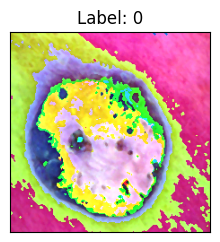

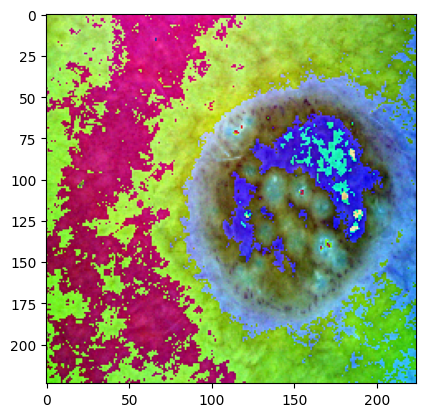

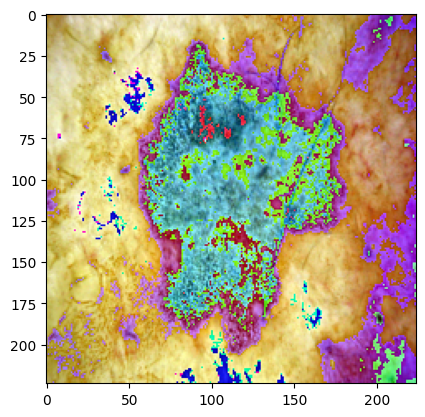

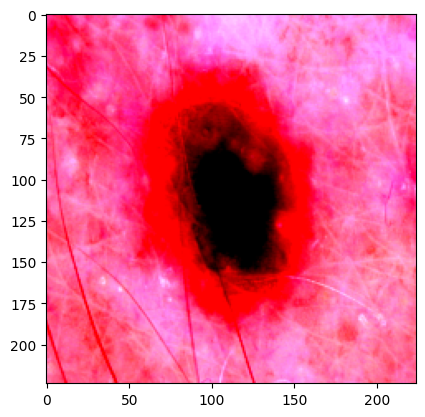

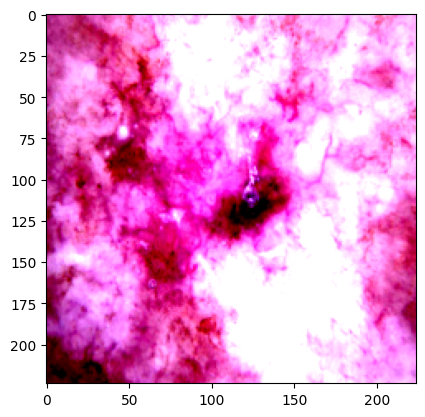

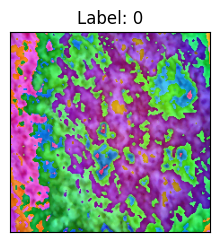

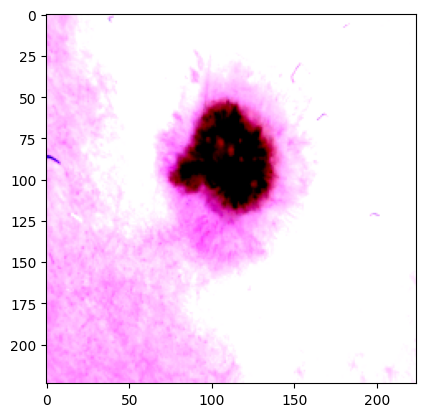

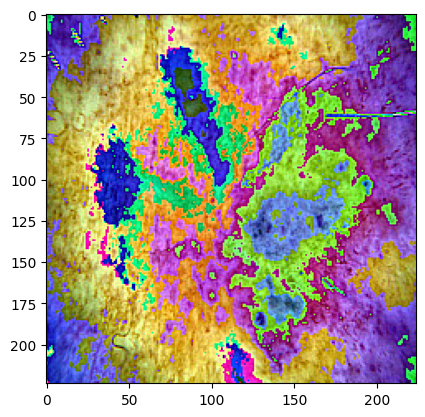

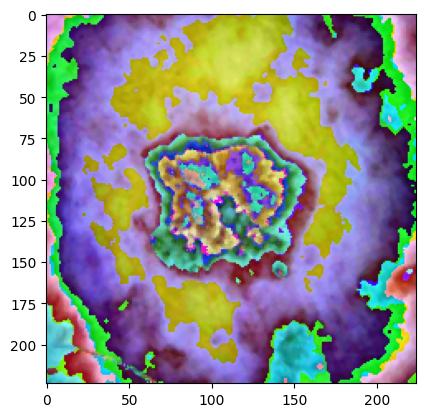

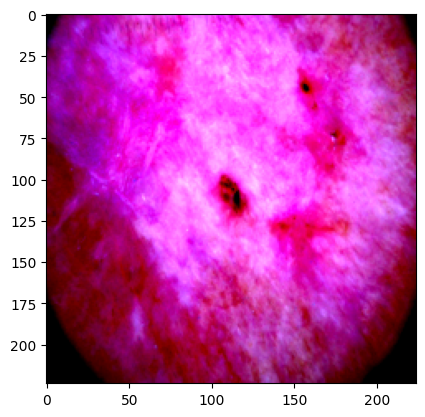

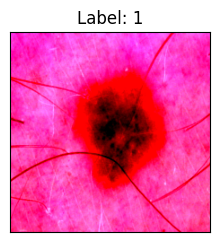

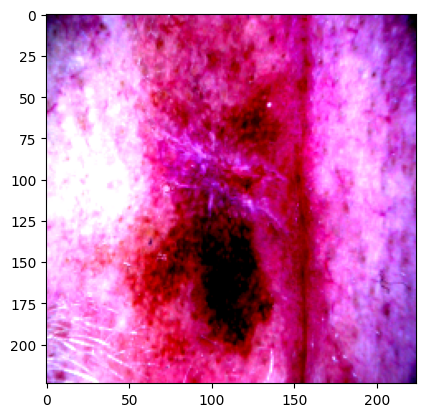

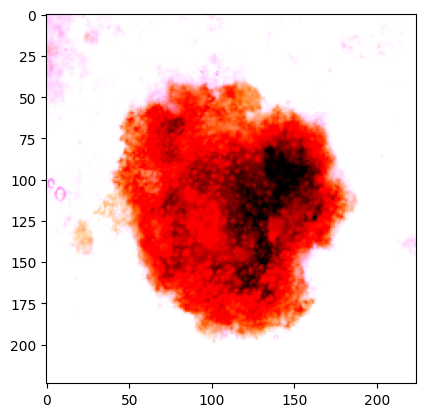

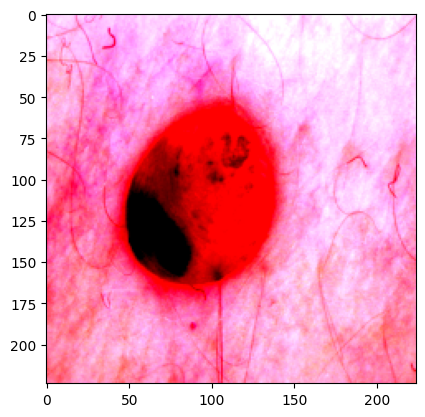

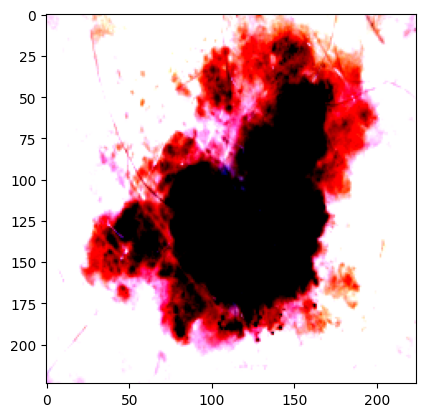

In [ ]:
def imshow(img, title=None):
    img = img.permute(1, 2, 0)
    img = img.detach().cpu().numpy()
    img = (img * 255).clip(0, 255).astype(np.uint8)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.pause(0.001)

def visualize_dataloader(dataloader, num_img=5, rows=3, cols=5):
    fig = plt.figure(figsize=(15, 15))

    data_iter = iter(dataloader)
    images, labels = next(data_iter)

    for i in range(num_img):
        ax = fig.add_subplot(rows, cols, i+1, xticks=[], yticks=[])
        # For one-hot encoded labels
        if labels.ndim > 1:
            ax.set_title(f"Label: {labels[i].argmax().item()}")
        else:
            ax.set_title(f"Label: {labels[i].item()}")

        imshow(images[i])

    plt.show()

# Visualize 15 images in 3 rows and 5 columns
visualize_dataloader(train_loader, num_img=5, rows=3, cols=5)
visualize_dataloader(val_loader, num_img=5, rows=3, cols=5)
visualize_dataloader(test_loader, num_img=5, rows=3, cols=5)

# **Baseline Model Testing and Score**

In [ ]:
#Use Naive Bayes as it can be used for multiclassification for the different skin cancer
#First we need to extract the features and labels from the data loaders and flatten the image pixels
from sklearn.naive_bayes import GaussianNB

#Establishing Base Model Naive Bayes for HAM1000
def NaiveBayes_model(training_dataset, training_labels, testing_dataset, testing_labels):
  model = GaussianNB() #Defining model

  model.fit(training_dataset, training_labels) #Fit model to training dataset

  testing_prediction = model.predict(testing_dataset) #Make predictions

  #For debugging purposes: print the prediction and test labels
  #print(testing_prediction)
  #print(testing_labels)

  #Calculate score
  correct = 0
  for i in range(len(testing_prediction)):
    if testing_prediction[i] == testing_labels[i]:
      correct += 1
    else:
      pass
  score = 100*(correct/len(testing_prediction))

  #score = 100*(1-sum(abs(testing_prediction - testing_labels))/len(testing_prediction))
  return print("Naive Bayes Test:", score)

In [ ]:
def loader_to_numpy(loader, device='cuda'):
    data_list = []
    labels_list = []

    # Disable gradients for faster computations
    with torch.no_grad():
        for data, labels in loader:
            data = data.to(device).view(data.size(0), -1)  # Flatten the data on the GPU
            labels = labels.to(device)
            data_list.append(data)  # Keep the data on the GPU
            labels_list.append(labels)

    # Concatenate all batches into a single tensor
    data = torch.cat(data_list, dim=0)
    labels = torch.cat(labels_list, dim=0)

    # Decode one-hot encoded labels to class indices
    labels = torch.argmax(labels, axis=1)

    # Convert to numpy if needed (this will move the data back to CPU)
    data_np = data.cpu().numpy()
    labels_np = labels.cpu().numpy()

    return data_np, labels_np

# Run on GPU
training_dataset, training_labels = loader_to_numpy(train_loader, device='cuda')
testing_dataset, testing_labels = loader_to_numpy(test_loader, device='cuda')


In [ ]:
NaiveBayes_model(training_dataset, training_labels, testing_dataset, testing_labels)

# **Primary Model**

In [ ]:
#create our model to train
#Define model
class SkinCancerCNN(nn.Module):
  def __init__(self):
    super(SkinCancerCNN, self).__init__()
    self.name = 'SkinCancerCNN'

    self.conv1 = nn.Conv2d(in_channels=3, out_channels=256, kernel_size=3, padding=1)
    self.BatchNorm1= nn.BatchNorm2d(256)

    self.conv2 = nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1)
    self.BatchNorm2= nn.BatchNorm2d(128)

    self.conv3 = nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1)
    self.BatchNorm3= nn.BatchNorm2d(64)

    self.conv4 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, padding=1)
    self.BatchNorm4= nn.BatchNorm2d(32)

    self.conv5 = nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, padding=1)
    self.BatchNorm5= nn.BatchNorm2d(16)


    self.dropout = nn.Dropout(p=0.4) #50% drop out
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    self.flatten = nn.Flatten()

    self.fc1 = nn.Linear(256, 64)
    self.fc2 = nn.Linear(64, 7)

  def forward(self, x):

    #print(x)


    x = self.conv1(x)
    x = self.BatchNorm1(x)
    x = F.relu(x)
    x = self.pool(x)  # output is 256x64x64

    x = self.conv2(x)
    x = self.BatchNorm2(x)
    x = F.relu(x) # output is 128x64x64
    x = self.pool(x)  # output is 128x32x32
    x = self.dropout(x)

    x = self.conv3(x)
    x = self.BatchNorm3(x)
    x = F.relu(x)
    x = self.pool(x)# output is 64x32x32

    x = self.conv4(x)
    x = self.BatchNorm4(x)
    x = F.relu(x)
    x = self.pool(x)# output is 32x32x32
    x = self.dropout(x)

    x = self.conv5(x)
    x = self.BatchNorm5(x)
    x = F.relu(x)
    x = self.pool(x)# output is 16x32x32

    x = self.flatten(x)
    #print(x.shape)
    x = self.fc1(x)
    x = F.relu(x)

    x = self.dropout(x)

    x = self.fc2(x)

    # print(f"Final output: {x.shape}")
    return x

SkinCancerCNN = SkinCancerCNN().to(device)

In [ ]:
class SkinCancerCNN2(nn.Module):
  def __init__(self):
    super(SkinCancerCNN2, self).__init__()
    self.name = 'SkinCancerCNN2'

    self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

    # New layer added
    self.conv4 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
    self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

    # New layer added
    self.conv5 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
    self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.dropout1 = nn.Dropout(p=0.4) # Increase dropout rate to 40%

    self.flatten = nn.Flatten()

    self.fc1 = nn.Linear(512 * 4 * 4, 256)

    self.dropout2 = nn.Dropout(p=0.5)  # Additional dropout layer

    self.fc2 = nn.Linear(256, 128)

    self.fc3 = nn.Linear(128, 7)

  def forward(self, x):
    x = self.conv1(x)
    x = F.relu(x)
    x = self.pool1(x)

    x = self.conv2(x)
    x = F.relu(x)
    x = self.pool2(x)

    x = self.conv3(x)
    x = F.relu(x)
    x = self.pool3(x)

    x = self.conv4(x)
    x = F.relu(x)
    x = self.pool4(x)

    x = self.conv5(x)
    x = F.relu(x)
    x = self.pool5(x)

    x = self.dropout1(x)

    x = self.flatten(x)

    x = self.fc1(x)
    x = F.relu(x)

    x = self.dropout2(x)

    x = self.fc2(x)
    x = F.relu(x)

    x = self.fc3(x)

    return x

SkinCancerCNN2 = SkinCancerCNN2().to(device)

In [ ]:
class SkinCancerCNN3(nn.Module):
  def __init__(self):
    super(SkinCancerCNN3, self).__init__()
    self.name = 'SkinCancerCNN3'


    #3 Convolutional Layers
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)

    #1 Pooling Layer
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    #1 Batch Normalization Layer
    self.BatchNorm1= nn.BatchNorm2d(64)
    self.BatchNorm2= nn.BatchNorm2d(128)
    self.BatchNorm3= nn.BatchNorm2d(256)

    #2 Dropout Layer
    self.dropout1 = nn.Dropout(p=0.2) # Increase dropout rate to 20%
    self.dropout2 = nn.Dropout(p=0.3)  # Additional dropout layer

    self.flatten = nn.Flatten()

    #3 Fully-Connected Linear Layers
    self.fc1 = nn.Linear(64*56*56, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 7)

  def forward(self, x):
    x = self.conv1(x)
    x = F.relu(x)
    x = self.BatchNorm1(x)
    x = self.pool(x)
    x = self.dropout1(x)

    x = self.conv2(x)
    x = F.relu(x)
    x = self.BatchNorm2(x)
    x = self.pool(x)
    x = self.dropout1(x)

    x = self.conv3(x)
    x = F.relu(x)
    x = self.BatchNorm3(x)
    x = self.pool(x)
    x = self.dropout1(x)

    x = self.flatten(x)

    x = self.fc1(x)
    x = F.relu(x)
    x = self.dropout2(x)

    x = self.fc2(x)
    x = F.relu(x)
    x = self.dropout2(x)

    x = self.fc3(x)

    return x

SkinCancerCNN3 = SkinCancerCNN3().to(device)

# **Train Model**

In [ ]:
#plot the accuracy curves
def plot_curves(train_acc, val_acc):
    plt.figure(figsize=(10, 6))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curves')
    plt.legend()

In [ ]:
#used for checkpointing, creates a name for current model configs
def get_model_name(name, batch_size, learning_rate, epoch):
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name, batch_size, learning_rate, epoch)
    return path

In [ ]:
torch.cuda.empty_cache()

In [ ]:
import torch.optim.lr_scheduler as lr_scheduler

# Assuming use_cuda and device are already defined
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

# Define the get_accuracy function
def get_accuracy(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():  # Disable gradient computation
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images.float())
            _, predicted = torch.max(outputs, 1)

            # print(predicted)
            # print(labels)

            correct_predictions += (predicted == torch.argmax(labels, dim=1)).sum().item()
            #correct_predictions += (predicted == labels).all(dim=1).sum().item()  # Adjusted for integer labels
            total_samples += labels.size(0)

    accuracy = correct_predictions / total_samples
    return accuracy

# Define the train function
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler=None):
    iters, losses, train_acc, val_acc = [], [], [], []

    for epoch in range(num_epochs):
        running_loss = 0.0
        model.train()  # Set the model to train mode

        for images, labels in train_loader:
            # To Enable GPU Usage
            if use_cuda and torch.cuda.is_available():
                images, labels = images.cuda(), labels.cuda()
                model.cuda()

            images, labels = images.to(device), labels.to(device)  # Move data to GPU
            optimizer.zero_grad()  # Zero the gradients
            # Forward pass
            outputs = model(images.float())
            loss = criterion(outputs, labels.float())
            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_accuracy = get_accuracy(model, train_loader, device)
        val_accuracy = get_accuracy(model, val_loader, device)

        train_acc.append(train_accuracy)
        val_acc.append(val_accuracy)

        if scheduler is not None:
            scheduler.step(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Accuracy: {val_accuracy:.4f}')

    plot_curves(train_acc, val_acc)

# **Training and Tuning Hyperparameters**


In [ ]:
torch.cuda.empty_cache()

In [ ]:
#Select Model Here
model = SkinCancerCNN3

Epoch [1/20], Loss: 1.9592, Train Accuracy: 0.7992, Val Accuracy: 0.8041
Epoch [2/20], Loss: 0.6351, Train Accuracy: 0.8096, Val Accuracy: 0.8131
Epoch [3/20], Loss: 0.5951, Train Accuracy: 0.8075, Val Accuracy: 0.8108
Epoch [4/20], Loss: 0.5742, Train Accuracy: 0.8096, Val Accuracy: 0.8103
Epoch [5/20], Loss: 0.5538, Train Accuracy: 0.8116, Val Accuracy: 0.8121
Epoch [6/20], Loss: 0.5354, Train Accuracy: 0.8184, Val Accuracy: 0.8136
Epoch [7/20], Loss: 0.5199, Train Accuracy: 0.8298, Val Accuracy: 0.8290
Epoch [8/20], Loss: 0.5081, Train Accuracy: 0.8413, Val Accuracy: 0.8285
Epoch [9/20], Loss: 0.4941, Train Accuracy: 0.8394, Val Accuracy: 0.8264
Epoch [10/20], Loss: 0.4865, Train Accuracy: 0.8465, Val Accuracy: 0.8377
Epoch [11/20], Loss: 0.4757, Train Accuracy: 0.8412, Val Accuracy: 0.8272
Epoch [12/20], Loss: 0.4618, Train Accuracy: 0.8481, Val Accuracy: 0.8351
Epoch [13/20], Loss: 0.4440, Train Accuracy: 0.8607, Val Accuracy: 0.8390
Epoch [14/20], Loss: 0.4432, Train Accuracy: 0.

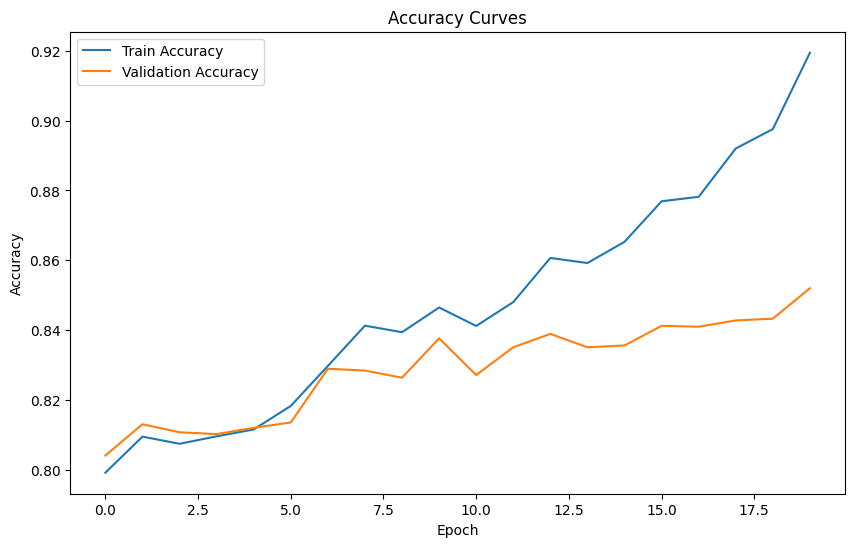

In [ ]:
# Train the model
lr = 1e-3
num_epochs = 20
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()  # Multi-classification loss function applies softmax
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, eps=1e-4)
train(model, train_loader, val_loader, criterion, optimizer, num_epochs=num_epochs)

In [ ]:
#save the model
torch.save(model.state_dict(), 'model.pth')

In [ ]:
#get the shape of the dataloaders
for images, labels in  train_loader:
    print(images.shape)
    print(labels.shape)
    break
for images, labels in  val_loader:
    print(images.shape)
    print(labels.shape)
    break
for images, labels in  test_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([128, 3, 224, 224])
torch.Size([128, 7])
torch.Size([128, 3, 224, 224])
torch.Size([128, 7])
torch.Size([128, 3, 224, 224])
torch.Size([128, 7])


In [ ]:
from sklearn.metrics import classification_report

# test the accuracy
def get_predictions(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode

    with torch.no_grad():  # Disable gradient computation
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images.float())
            _, predicted = torch.max(outputs, 1)
            #decode the labels
            labels = torch.argmax(labels, dim=1)

    return predicted, labels

y_pred, y_truth = get_predictions(model, test_loader, device)

#convert y_pred and y_truth to numpys
y_pred = y_pred.cpu().numpy()
y_truth = y_truth.cpu().numpy()


print(classification_report(y_pred, y_truth))

              precision    recall  f1-score   support

           0       0.27      0.60      0.37         5
           1       0.98      0.76      0.86        67
           2       0.00      0.00      0.00         0
           3       0.12      0.33      0.18         3
           4       1.00      1.00      1.00         1
           5       0.50      0.60      0.55         5
           6       0.67      1.00      0.80         2

    accuracy                           0.73        83
   macro avg       0.51      0.61      0.54        83
weighted avg       0.87      0.73      0.79        83



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
#For testing the model
test_accuracy = get_accuracy(model, test_loader, device)
print(f'Test Accuracy: {test_accuracy:.2%}')

Test Accuracy: 78.08%


# **Visualize Predictions**

In [ ]:
#load the pretrained weights and bias
trained_path = '/content/drive/MyDrive/Colab Notebooks/APS360/Project/model.pth'

model.load_state_dict(torch.load(trained_path))

<All keys matched successfully>

In [ ]:
torch.cuda.empty_cache()

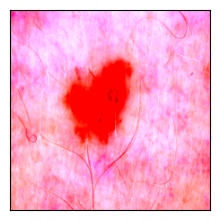

True Label:  1
Predicted Label:  1


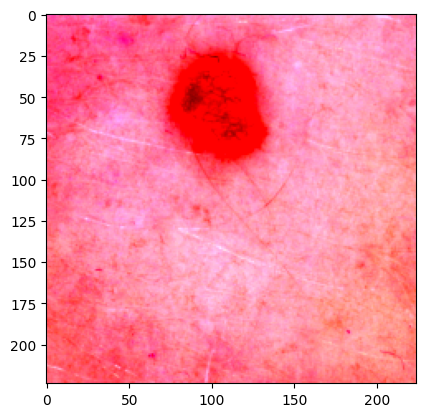

True Label:  1
Predicted Label:  1


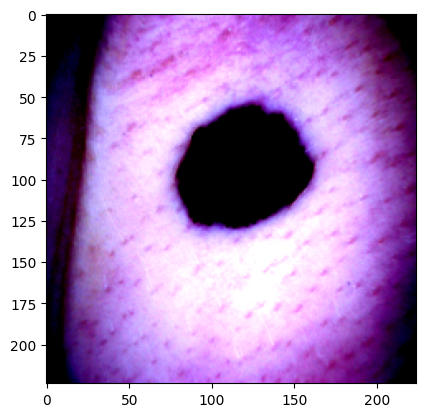

True Label:  1
Predicted Label:  1


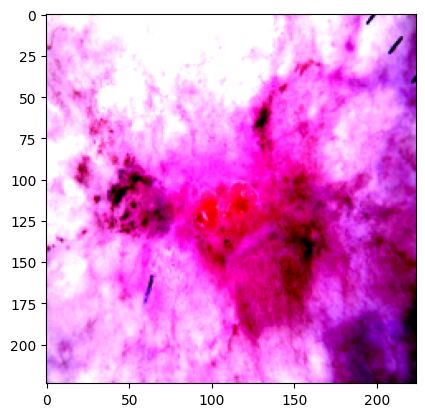

True Label:  5
Predicted Label:  6


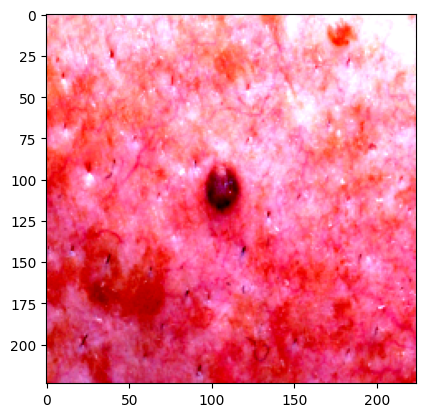

True Label:  1
Predicted Label:  1


In [ ]:
#display 5 pictures from test loader with truth values and predictions
def imshow(img, title=None):
    img = img.permute(1, 2, 0)
    img = img.detach().cpu().numpy()
    img = (img * 255).clip(0, 255).astype(np.uint8)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.pause(0.001)

def show_predictions(model, dataloader, num_img=5, device='cuda'):
    model.to(device)
    model.eval()  # Set the model to evaluation mode
    fig = plt.figure(figsize=(15, 15))

    data_iter = iter(dataloader)
    images, labels = next(data_iter)

    # Move images and labels to the GPU if available
    images = images.to(device)
    labels = labels.to(device)

    # Get model predictions
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for i in range(num_img):
        ax = fig.add_subplot(1, num_img, i+1, xticks=[], yticks=[])
        imshow(images[i].cpu())  # Move image back to CPU for displaying

        true_label = labels[i].item() if labels.ndim == 1 else labels[i].argmax().item()
        pred_label = preds[i].item()
        print("True Label: ", true_label)
        print("Predicted Label: ", pred_label)
        ax.set_title(f"True: {true_label}, Pred: {pred_label}")

    plt.show()

# Show 5 images with their true and predicted labels
show_predictions(model, test_loader, num_img=5, device='cuda')

# **Tuning Transfer Learning**

In [ ]:
#Transfer Model (*Note: Skip the training Step)
from torchvision.models import resnet152, ResNet152_Weights
weights = ResNet152_Weights.DEFAULT
transfer_model = resnet152(weights=weights)
transfer_model = transfer_model.to(device)


#import pretrained resnet50
from torchvision.models import resnet50, ResNet50_Weights
weights = ResNet50_Weights.DEFAULT
rn50 = resnet50(weights=weights)

ctr=0
for param in rn50.parameters():

  #unfreeze the first  40 layers

  param.requires_grad = False


  ctr +=1
#change the final layer to have enough output classes
rn50.fc = nn.Linear(rn50.fc.in_features, 7)

for param in rn50.fc.parameters():
    param.requires_grad = True


rn50 = rn50.to(device)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth
100%|██████████| 230M/230M [00:05<00:00, 48.0MB/s]
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 96.4MB/s]


In [ ]:
model2=rn50

Epoch [1/3], Loss: 0.7239, Train Accuracy: 0.8172, Val Accuracy: 0.8167
Epoch [2/3], Loss: 0.5070, Train Accuracy: 0.8365, Val Accuracy: 0.8264
Epoch [3/3], Loss: 0.4488, Train Accuracy: 0.8536, Val Accuracy: 0.8356


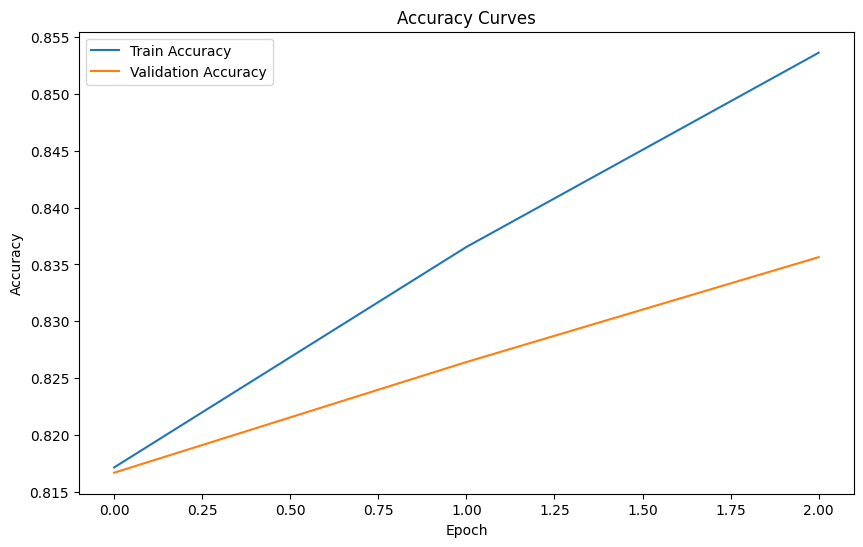

In [ ]:
# Train the model
lr = 1e-3
num_epochs = 3
optimizer = optim.Adam(model2.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()  # Multi-classification loss function applies softmax
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, eps=1e-4)
train(model2, train_loader, val_loader, criterion, optimizer, num_epochs=num_epochs)

In [ ]:
y_pred, y_truth = get_predictions(model2, test_loader, device)

#convert y_pred and y_truth to numpys
y_pred = y_pred.cpu().numpy()
y_truth = y_truth.cpu().numpy()


print(classification_report(y_pred, y_truth))

              precision    recall  f1-score   support

           0       0.45      0.56      0.50         9
           1       0.96      0.81      0.88        62
           2       0.00      0.00      0.00         0
           3       0.50      0.56      0.53         9
           5       0.33      1.00      0.50         2
           6       0.50      1.00      0.67         1

    accuracy                           0.76        83
   macro avg       0.46      0.65      0.51        83
weighted avg       0.84      0.76      0.79        83



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
get_accuracy(model2, test_loader, device)

0.7418871692461309

In [ ]:
#save the model
torch.save(model2.state_dict(), 'model2.pth')

#For testing the model
test_accuracy = get_accuracy(model2, test_loader, device)
print(f'Test Accuracy: {test_accuracy:.2%}')

# **Demonstration**

In [ ]:
#Define the image transformation pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize the image to the size expected by the model
    transforms.ToTensor(),          # Convert the image to a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize as per training
])

#Load the image
image_path = '/content/drive/MyDrive/Colab Notebooks/APS360/Project/Demo 2.jpg'  # Replace with the path to your image
image = Image.open(image_path).convert('RGB')  # Ensure the image is in RGB format

#Apply the transformations to the image
image_tensor = transform(image)

#Add a batch dimension (since the model expects a batch of images)
image_tensor = image_tensor.unsqueeze(0)

#Make predictions with the model
model = model.to(torch.device('cpu'))
with torch.no_grad():  # No need to compute gradients for inference
    output = model(image_tensor)
    _ , predicted_class = torch.max(output, 1)  # Get the class with the highest probability

#Print the predicted class
print(f"Predicted class: {predicted_class.item()}")

Predicted class: 1


# **Loading/Splitting Full Dataset: (Old way of dataloading)**

In [ ]:
#data loading
X=np.asarray(metadata_balanced['image'].tolist())
X=X/255 #normalize
y=metadata_balanced['label']
#convert y into np array
y=y.to_numpy()

#now into tensor
y=torch.from_numpy(y)
y_catog=F.one_hot(y, num_classes=7)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y_catog, test_size=0.2, random_state=42)
#convert xtrain and y train into data sets
x_train=torch.from_numpy(x_train)
x_test=torch.from_numpy(x_test)


In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

#check type of x and y train
print(type(x_train))
print(type(y_train))
print(type(x_test))
print(type(y_test))

torch.Size([2867, 128, 128, 3])
torch.Size([717, 128, 128, 3])
torch.Size([2867, 7])
torch.Size([717, 7])
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [ ]:
#check the values in x_train
print(x_train.shape)
#permute
x_train=x_train.permute(0,3,1,2)
x_test=x_test.permute(0,3,1,2)

print(x_train.shape)

torch.Size([2867, 128, 128, 3])
torch.Size([2867, 3, 128, 128])


In [ ]:
#convert this into dataset

x_train_tensor = x_train.clone().detach()
y_train_tensor = y_train.clone().detach()

x_test_tensor = x_test.clone().detach()
y_test_tensor = y_test.clone().detach()


train_dataset = torch.utils.data.TensorDataset(x_train_tensor.to(device), y_train_tensor.to(device))
test_dataset = torch.utils.data.TensorDataset(x_test_tensor.to(device), y_test_tensor.to(device))

#split train into train and val (75% of 80 gives total split to 60/20/20)
train_size=int(0.75*len(train_dataset))
val_size=len(train_dataset)-train_size
train_dataset, val_dataset=torch.utils.data.random_split(train_dataset, [train_size, val_size]) #random split used here

#convert into dataloader
bs=128
train_loader=torch.utils.data.DataLoader(train_dataset, batch_size=bs, shuffle=True)
test_loader=torch.utils.data.DataLoader(test_dataset, batch_size=bs, shuffle=True)
val_loader=torch.utils.data.DataLoader(val_dataset, batch_size=bs, shuffle=True)

In [ ]:
#check the shape of test_dataset
print(len(train_dataset))
print(len(test_dataset))
print(len(val_dataset))

2150
717
717


Check the shape of all the dataloaders

In [ ]:
# Function to show a tensor image with its label
def show_image(tensor, label=None):
    # Convert tensor to numpy array
    np_img = tensor.numpy()

    # Normalize the image for display
    np_img = (np_img - np_img.min()) / (np_img.max() - np_img.min())
    # Display the image
    plt.imshow(np_img)
    if label is not None:
        plt.title(f"Label: {label}")
    plt.axis('off')  # Hide the axes
    plt.show()